# サンプルに温度駆動力

In [953]:
import numpy as np
from numpy.random import *
import matplotlib.pyplot as plt
import math

In [954]:
nx = 64 # number of computational grids along x direction
ny = nx # number of computational grids along y direction
number_of_grain = 2 # total number of grains: N
dx, dy = 1e-4, 1e-4 # spacing of computational grids [m]
dt = 0.01 # time increment [s]
nsteps = 10000 # total number of time-steps
pi = np.pi 
sigma = 1.0 # grain boundary energy [J/m2]
delta = 10.0 * dx # thickness of diffuse interface
T_melt = 1687.15 # 融点Tm [K]
G = 1.0e+03 # 温度勾配 [K/m]
V_pulling = 1.0e-03 # 引き抜き速度 [m/s]
latent = 4.15e+07 # 潜熱 [J/mol]

In [955]:
aaa = 2.0 / pi * np.sqrt(2.0*delta*sigma) # gradient energy coefficient
www = 4 * sigma/delta # height of double-obstacle potential
pmobi = pi*pi/(8.*delta)*3.0e-13 # mobility of phase-field 
print(f"{aaa} aaa, {www} www, {pmobi} pmobi")

0.028470501736687085 aaa, 4000.0 www, 3.701101650408509e-10 pmobi


In [956]:
wij = np.zeros((number_of_grain,number_of_grain)) # array for the height of double-obstacle potential
aij = np.zeros((number_of_grain,number_of_grain)) # array for the gradient energy coefficient
mij = np.zeros((number_of_grain,number_of_grain)) # array for the mobility of phase-field 

In [957]:
phi = np.zeros((number_of_grain,nx,ny)) 
phi_new = np.zeros((number_of_grain,nx,ny)) 
temp = np.zeros((nx,ny))
temp_new = np.zeros((nx,ny))
mf = np.zeros((15,nx,ny),dtype = int) 
nf = np.zeros((nx,ny),dtype = int) 

In [958]:
gb = np.zeros((nx,ny)) 
gi = np.zeros((nx,ny),dtype = int) 

In [959]:
for i in range(0,number_of_grain):
    for j in range(0,number_of_grain):
        wij[i,j] = www
        aij[i,j] = aaa
        mij[i,j] = pmobi
        if i == j:
            wij[i,j] = 0.0
            aij[i,j] = 0.0
            mij[i,j] = 0.0
        if (i == 0 and j != 0) or (i != 0 and j == 0):
            mij[i,j] = pmobi*100 #固液界面は早い
        else:
            mij[i,j] = pmobi # 固相同士は遅いまま

In [960]:
def update_nfmf(phi,mf,nf):
    for m in range(ny):
        for l in range(nx):
            l_p = l + 1
            l_m = l - 1
            m_p = m + 1
            m_m = m - 1
            if l_p > nx-1:
                l_p = nx - 1
            if l_m < 0:
                l_m = 0
            if m_p > ny-1:
                m_p = ny - 1
            if m_m < 0:
                m_m = 0
            n = 0
            for i in range(number_of_grain):
                if phi[i,l,m] > 0.0 or (phi[i,l,m] == 0.0 and phi[i,l_p,m] > 0.0 or phi[i,l_m,m] > 0.0 or phi[i,l,m_p] > 0.0 or phi[i,l,m_m] > 0.0):
                    n += 1
                    mf[n-1,l,m] = i
            nf[l,m] = n

In [961]:
def update_phasefield(phi,phi_new,mf,nf,temp):
    for m in range(ny):
        for l in range(nx):
            l_p = l + 1
            l_m = l - 1
            m_p = m + 1
            m_m = m - 1
            if l_p > nx-1: 
                l_p = nx - 1
            if l_m < 0:
                l_m = 0
            if m_p > ny-1:
                m_p = ny - 1
            if m_m < 0:
                m_m = 0
            num_phase = nf[l,m]
            for n1 in range(nf[l,m]):
                i = mf[n1,l,m]
                dpi = 0.0
                for n2 in range(nf[l,m]):
                    j = mf[n2,l,m]
                    if i == j:
                        continue
                    driving_force = 0.0
                    current_temp = temp[l,m]
                    if i != 0 and j == 0:
                        # i(固) -> j(液) : 固相が増える方向 (+E)
                        driving_force = latent*(T_melt - current_temp)/T_melt
                    elif i == 0 and j != 0:
                        # i(液) -> j(固) : 固相が減る方向 (-E)
                        driving_force = -1*latent*(T_melt - current_temp)/T_melt
                    ppp = 0.0
                    for n3 in range(nf[l,m]):
                        k = mf[n3,l,m]
                        lap_phi_k = (phi[k,l_p,m] + phi[k,l_m,m] + phi[k,l,m_p] + phi[k,l,m_m] - 4.0*phi[k,l,m]) / (dx*dx)
                        term1 = (wij[i,k]-wij[j,k])*phi[k,l,m]
                        term2 = 0.5*(aij[i,k]**2 - aij[j,k]**2)*lap_phi_k
                        ppp += term1 + term2
                    phii_phij = phi[i,l,m]*phi[j,l,m]
                    term_force = (8.0/pi)*np.sqrt(np.max(phii_phij,0))*driving_force
                    dpi -= (2.0/float(num_phase))*mij[i,j]*(ppp - term_force)
                phi_new[i,l,m] = phi[i,l,m] + dpi *dt
    # 正規化処理 (合計を1にする)
    for m in range(ny):
        for l in range(nx):
            total = np.sum(phi_new[:,l,m])
            if total > 0:
                phi_new[:,l,m] /= total
            else:
                # 異常値回避
                phi_new[:,l,m] = phi[:,l,m]

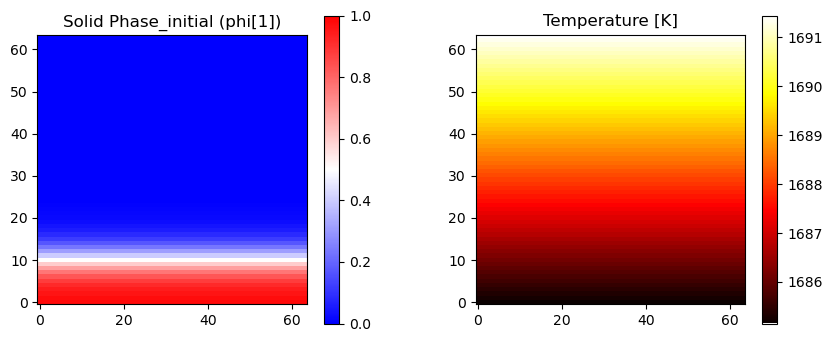

In [962]:
phi = np.zeros((number_of_grain,nx,ny))
phi_new = np.zeros((number_of_grain,nx,ny))
temp = np.zeros((nx,ny))
temp_new = np.zeros((nx,ny))
mf = np.zeros((15,nx,ny),dtype = int)
nf = np.zeros((nx,ny),dtype = int)

# --- 初期配置 ---
# シード（固相）の高さ [グリッド数]
seed_height = 10 

factor = 2 / delta 

# 界面のY座標 [m]
interface_pos = seed_height * dy

for m in range(ny):
    # 現在のY座標 [m]
    y = m * dy
    
    # 界面からの距離 (上が正、下が負)
    dist = y - interface_pos

    phi_solid = 0.5 * (1.0 - np.tanh(factor * dist))
    
    # 全グリッド(x方向)に同じ値を設定
    # 下部: 固相 (ID=1)
    phi[1, :, m] = phi_solid
    
    # 上部: 液相 (ID=0) (合計が1になるように)
    phi[0, :, m] = 1.0 - phi_solid

# --- 初期温度場の設定 ---
# 一方向凝固なので、高さ(y方向)に応じて温度を変える
for m in range(ny):
    # 界面 (seed_height) でちょうど融点 T_melt になるように設定する場合
    
    current_temp = T_melt - 1  + G * (m - seed_height) * dy
    temp[:, m] = current_temp

# --- プロット ---
fig = plt.figure(figsize=(10, 4))
plt.subplots_adjust(wspace=0.3)
        
# 固相(ID=1)の分布を表示
plt.subplot(1, 2, 1)
# phi[1] を表示 (転置 .T は x,y軸の向きに合わせて調整してください)
plt.imshow(phi[1].T, cmap='bwr', origin='lower', vmin=0, vmax=1) 
plt.title('Solid Phase_initial (phi[1])')
plt.colorbar()

# 温度場を表示
plt.subplot(1, 2, 2)
plt.imshow(temp.T, cmap="hot", origin='lower')
plt.title('Temperature [K]')
plt.colorbar()

plt.show()

In [ ]:
for nstep in range(1,nsteps+1):
    # print("Time step:", nstep)
    # update_nfmf(phi,mf,nf)
    # update_phasefield(phi,phi_new,mf,nf,temp,temp_new)
    # phi = phi_new
    # temp = temp_new
    # 1. アクティブな粒リスト(mf, nf)を更新
    cooling_rate = G * V_pulling * dt
    temp[:, :] -= cooling_rate
    update_nfmf(phi, mf, nf)
    
    # 2. 【重要】計算前に phi_new, temp_new を最新の phi, temp で初期化(コピー)
    # これをしないと、計算対象外(inactive)の粒が古い値のまま残ってしまいます
    phi_new[:] = phi[:]    
    # 3. フェーズフィールドと温度場の更新 (変化分を phi_new に上書き)
    update_phasefield(phi, phi_new, mf, nf, temp)

    # 4. バッファの入れ替え (コピーではなく参照の交換なので高速)
    phi, phi_new = phi_new, phi
    if nstep % 1000 == 0:
        print('nstep = ', nstep)
        for m in range(0,ny):
            for l in range(0,nx):
                gb[l,m] = np.sum(phi[:,l,m]*phi[:,l,m])
                phi_max = 0.
                for n in range(nf[l,m]):
                    i = mf[n,l,m]
                    if phi[i,l,m] > phi_max:
                        gi[l,m] = i
                        phi_max = phi[i,l,m]
        fig = plt.figure(figsize=(10, 4))
        plt.subplots_adjust(wspace=0.3)
                
        # 固相(ID=1)の分布を表示
        plt.subplot(1, 2, 1)
        # phi[1] を表示 
        plt.imshow(phi[1].T, cmap='bwr', origin='lower', vmin=0, vmax=1) 
        plt.title(f'Solid Phase (phi[1])_step{nstep}')
        plt.colorbar()

        # 温度場を表示
        plt.subplot(1, 2, 2)
        plt.imshow(temp.T, cmap="hot", origin='lower')
        plt.title(f'Temperature_step{nstep} [K]')
        plt.colorbar()
        plt.show()

C:\Users\Usami\AppData\Local\Temp\ipykernel_14248\2164543350.py:40: RuntimeWarning: invalid value encountered in sqrt
  term_force = (8.0/pi)*np.sqrt(np.max(phii_phij,0))*driving_force
